# QUESTION 1

### Part 1

In [12]:
import pandas as pd

df = pd.read_csv("dataset_unscaled.csv")
df['date'] = pd.to_datetime(df['date'])

print("\n1. What is the overall average closing price of gold?")
print(df['close'].mean())


print("\n2. What was the highest gold price ever recorded (High column)?")
print(df['high'].max())


print("\n3. On which date did gold have the lowest closing price?")
print(df.loc[df['close'].idxmin()][['date', 'close']])


print("\n4. Which year had the highest average closing price?")
df['year'] = df['date'].dt.year
print(df.groupby('year')['close'].mean().idxmax())


print("\n5. What is the correlation between gold closing price and USD index?")
print(df[['close', 'usd_index']].corr())


print("\n6. How many days did gold close higher than it opened?")
print((df['close'] > df['open']).sum())


print("\n7. Top 5 dates with the highest volume traded:")
print(df.nlargest(5, 'volume')[['date', 'volume']])


print("\n8. Monthly average gold closing price for each month:")
df['month'] = df['date'].dt.month
print(df.groupby('month')['close'].mean())


print("\n9. Dates where gold price dropped more than 1% from previous day:")
df['Return'] = (df['close'] - df['Close_lag1']) / df['Close_lag1']
result = df[df['Return'] < -0.01][['date', 'close', 'Close_lag1', 'Return']]
print(result)


print("\n10. Yearly maximum 'High' gold price:")
print(df.groupby('year')['high'].max())



1. What is the overall average closing price of gold?
2213.3770836036506

2. What was the highest gold price ever recorded (High column)?
4049.199951171875

3. On which date did gold have the lowest closing price?
date     2019-04-23 00:00:00
close            1269.300049
Name: 369, dtype: object

4. Which year had the highest average closing price?
2025

5. What is the correlation between gold closing price and USD index?
              close  usd_index
close      1.000000   0.469944
usd_index  0.469944   1.000000

6. How many days did gold close higher than it opened?
12865

7. Top 5 dates with the highest volume traded:
            date    volume
23692 2025-10-10  352500.0
1860  2019-11-26  346362.0
2358  2020-01-29  251274.0
1047  2019-07-29  224267.0
3644  2020-07-29  209835.0

8. Monthly average gold closing price for each month:
month
1     2156.955447
2     2060.270821
3     2025.866809
4     2164.415622
5     2084.011412
6     2030.915683
7     2077.048775
8     2134.355330
9  

## Part 2
### correlation matrix and other graphs made in assignment 1

## Part 3

### KNN For Regression

Train-test split done.
Running sklearn KNN...
Library KNN - MSE: 771.8815, R2: 0.9981
Creating random subsets for custom KNN...
Running CUSTOM KNN...
Custom KNN progress: 0/1000 processed
Custom KNN progress: 50/1000 processed
Custom KNN progress: 100/1000 processed
Custom KNN progress: 150/1000 processed
Custom KNN progress: 200/1000 processed
Custom KNN progress: 250/1000 processed
Custom KNN progress: 300/1000 processed
Custom KNN progress: 350/1000 processed
Custom KNN progress: 400/1000 processed
Custom KNN progress: 450/1000 processed
Custom KNN progress: 500/1000 processed
Custom KNN progress: 550/1000 processed
Custom KNN progress: 600/1000 processed
Custom KNN progress: 650/1000 processed
Custom KNN progress: 700/1000 processed
Custom KNN progress: 750/1000 processed
Custom KNN progress: 800/1000 processed
Custom KNN progress: 850/1000 processed
Custom KNN progress: 900/1000 processed
Custom KNN progress: 950/1000 processed
Custom KNN - MSE: 1119.1323, R2: 0.9974
Library KNN A

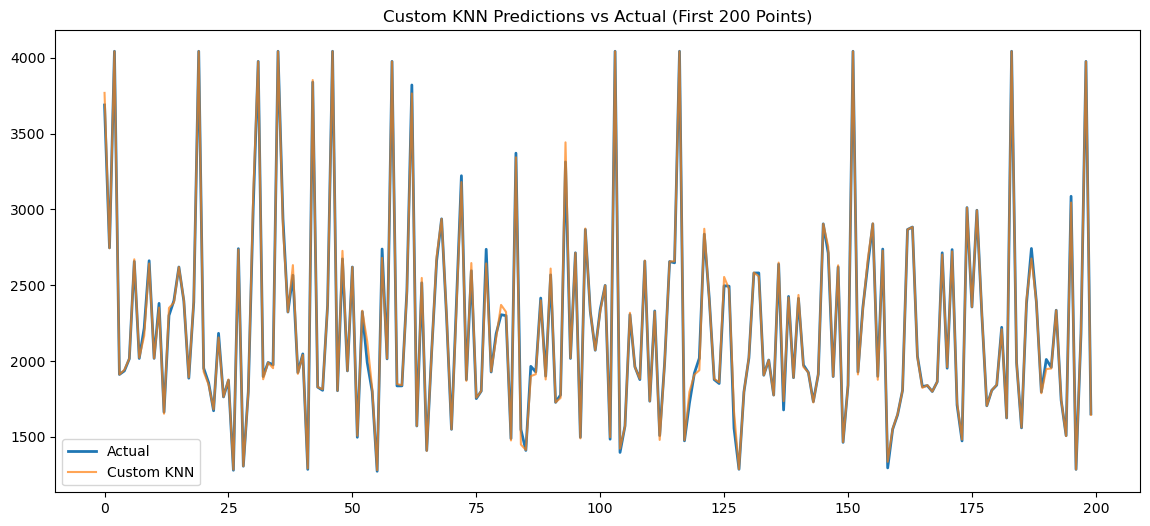

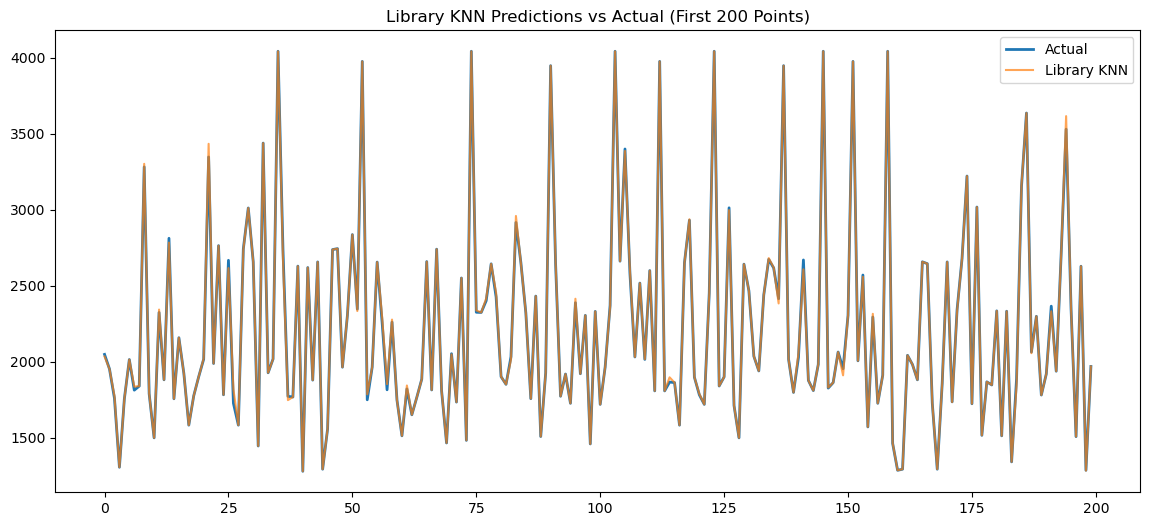

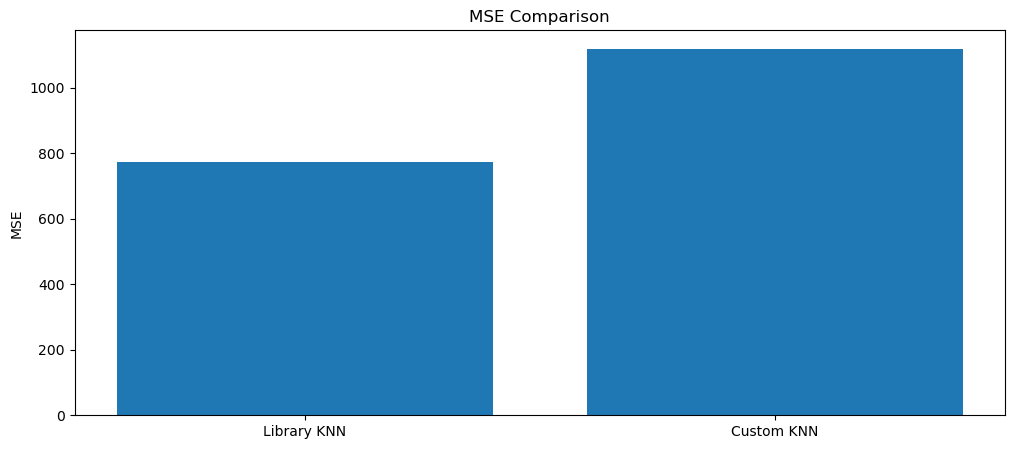

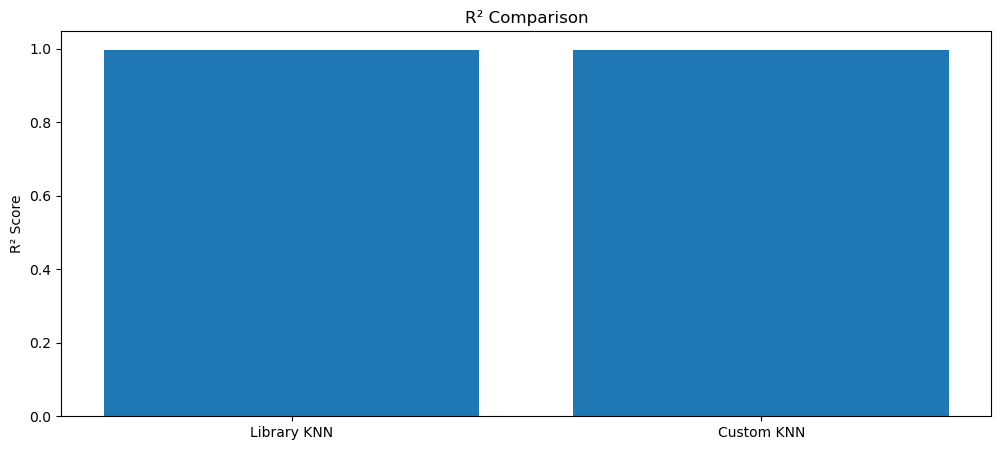

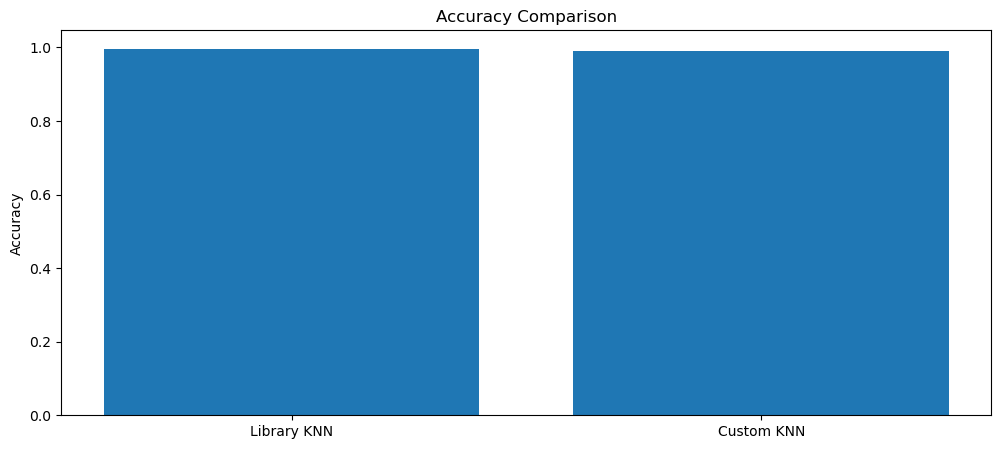

In [8]:
#using library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_scaled.csv')
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
features.remove('close')

X = df[features].values
y = df['close'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-test split done.")

k = 5
print("Running sklearn KNN...")

knn = KNeighborsRegressor(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred_lib = knn.predict(X_test)

mse_lib = mean_squared_error(y_test, y_pred_lib)
r2_lib = r2_score(y_test, y_pred_lib)

print(f"Library KNN - MSE: {mse_lib:.4f}, R2: {r2_lib:.4f}")

#custom KNN for regression
train_subset_size = 5000
test_subset_size = 1000

print("Creating random subsets for custom KNN...")

train_indices = np.random.choice(len(X_train), train_subset_size, replace=False)
test_indices = np.random.choice(len(X_test), test_subset_size, replace=False)

X_train_small = X_train[train_indices]
y_train_small = y_train[train_indices]

X_test_small = X_test[test_indices]
y_test_small = y_test[test_indices]


def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict_custom(X_train, y_train, X_test, k=5):
    y_pred = []
    for i, x in enumerate(X_test):
        if i % 50 == 0:
            print(f"Custom KNN progress: {i}/{len(X_test)} processed")

        distances = [euclidean_distance(x, x_train) for x_train in X_train]
        nn_indices = np.argsort(distances)[:k]
        pred = np.mean(y_train[nn_indices])
        y_pred.append(pred)
    return np.array(y_pred)


print("Running CUSTOM KNN...")
y_pred_custom = knn_predict_custom(X_train_small, y_train_small, X_test_small, k)

mse_custom = mean_squared_error(y_test_small, y_pred_custom)
r2_custom = r2_score(y_test_small, y_pred_custom)

print(f"Custom KNN - MSE: {mse_custom:.4f}, R2: {r2_custom:.4f}")



# Accuracy = 1 - (|pred - actual| / actual)
def regression_accuracy(y_true, y_pred):
    return np.mean(1 - (np.abs(y_true - y_pred) / y_true))

acc_lib = regression_accuracy(y_test, y_pred_lib)
acc_custom = regression_accuracy(y_test_small, y_pred_custom)

print(f"Library KNN Accuracy: {acc_lib:.4f}")
print(f"Custom KNN Accuracy: {acc_custom:.4f}")

#GRAPHICAL COMPARISON OF PREDICTIONS

plt.figure(figsize=(14,6))
plt.plot(y_test_small[:200], label="Actual", linewidth=2)
plt.plot(y_pred_custom[:200], label="Custom KNN", alpha=0.7)
plt.title("Custom KNN Predictions vs Actual (First 200 Points)")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(y_test[:200], label="Actual", linewidth=2)
plt.plot(y_pred_lib[:200], label="Library KNN", alpha=0.7)
plt.title("Library KNN Predictions vs Actual (First 200 Points)")
plt.legend()
plt.show()

#SIDE-BY-SIDE COMPARISON

models = ["Library KNN", "Custom KNN"]
mse_values = [mse_lib, mse_custom]
r2_values = [r2_lib, r2_custom]
acc_values = [acc_lib, acc_custom]

plt.figure(figsize=(12,5))
plt.bar(models, mse_values)
plt.title("MSE Comparison")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(12,5))
plt.bar(models, r2_values)
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.show()

plt.figure(figsize=(12,5))
plt.bar(models, acc_values)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


## Decision Tree (Regression)

📌 Decision Tree Regression Results
MSE: 139.1334
MAE: 9.0288
R² Score: 0.9997
MAPE: 0.44%
Regression Accuracy: 99.56%


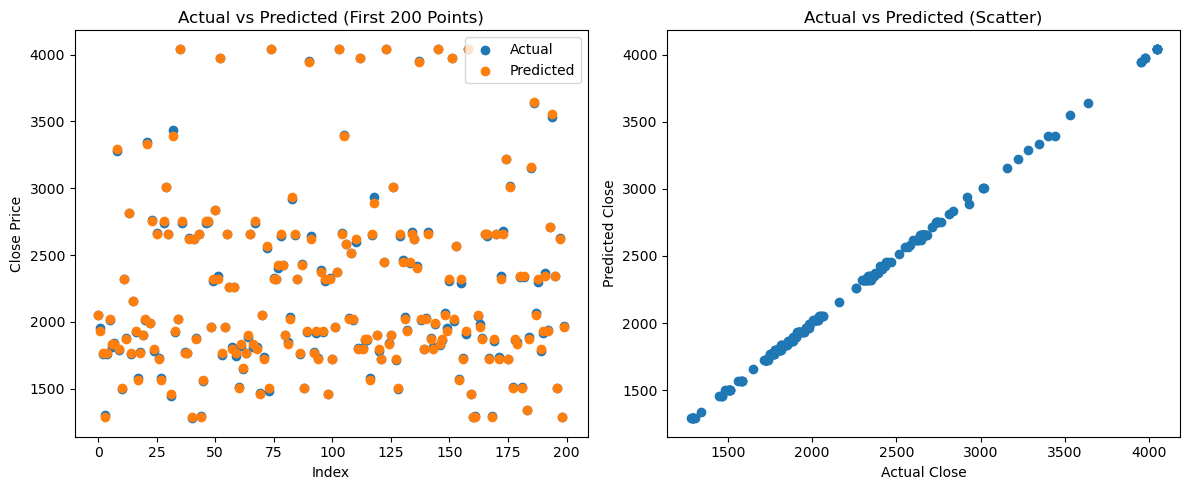

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

df = pd.read_csv("dataset_unscaled.csv")      #unscaled dataset for decision trees

features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
features.remove('close')

X = df[features].values
y = df['close'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor(max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print("📌 Decision Tree Regression Results")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Regression Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_test[:200])), y_test[:200], label="Actual")
plt.scatter(range(len(y_pred[:200])), y_pred[:200], label="Predicted")
plt.title("Actual vs Predicted (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_test[:200], y_pred[:200])
plt.title("Actual vs Predicted (Scatter)")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")

plt.tight_layout()
plt.show()

## SVM

## Naive Bayes

## Logistic Regression

## Enssemble Learning Algorithms